# VectorFFT vs FFTW vs Intel MKL — Performance Comparison

Split-complex batched 1D FFT (double precision, single-threaded AVX2)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'

In [17]:
# Raw benchmark data from bench_planner.c output
# (N, K, ours_ns, fftw_ns, mkl_ns)
data = [
    (256, 32, 5673.0, 16990.2, 12152.5),
    (256, 256, 57635.0, 143570.0, 103925.0),
    (256, 1024, 402075.0, 715240.0, 572265.0),
    (1024, 32, 31723.3, 70260.0, 57470.0),
    (1024, 256, 492590.0, 837665.0, 687885.0),
    (1024, 1024, 2492880.0, 3338950.0, 3155740.0),
    (4096, 32, 324230.0, 601395.0, 362305.0),
    (4096, 256, 3086035.0, 5588065.0, 3645745.0),
    (4096, 1024, 23391000.0, 38359380.0, 23078850.0),
    (16384, 32, 1806235.0, 5481325.0, 1956690.0),
    (16384, 256, 18436605.0, 101104860.0, 20619815.0),
    (60, 32, 784.4, 3239.8, 3544.4),
    (60, 256, 6993.8, 29001.5, 33958.5),
    (60, 1024, 41160.0, 129720.0, 148810.0),
    (200, 32, 4659.6, 12372.4, 13636.5),
    (200, 256, 34840.0, 108945.0, 114995.0),
    (200, 1024, 308150.0, 604695.0, 592895.0),
    (1000, 32, 30454.8, 75819.4, 80054.8),
    (1000, 256, 460385.0, 957270.0, 871445.0),
    (1000, 1024, 2326215.0, 4064430.0, 3982745.0),
    (5000, 32, 302330.0, 1121350.0, 670720.0),
    (5000, 256, 3876140.0, 10980025.0, 5602105.0),
    (5000, 1024, 21513075.0, 76916320.0, 34268740.0),
    (10000, 32, 656845.0, 3215560.0, 1398145.0),
    (10000, 256, 9070750.0, 61916520.0, 12500250.0),
    (10000, 1024, 51884655.0, 350036390.0, 76945505.0),
    (20000, 32, 1842905.0, 7983290.0, 3089815.0),
    (20000, 256, 23031115.0, 134442775.0, 31710880.0),
    (50000, 32, 5864495.0, 36718520.0, 8664815.0),
    (50000, 256, 62886105.0, 806097790.0, 89504545.0),
    (49, 32, 717.9, 3397.3, 3011.5),
    (49, 256, 6850.6, 27603.8, 28340.5),
    (143, 32, 3853.7, 14797.7, 12068.8),
    (143, 256, 42244.4, 92359.3, 99463.0),
    (875, 32, 26528.6, 91602.9, 77565.7),
    (875, 256, 357155.0, 1094155.0, 807425.0),
    (2401, 32, 116315.0, 306000.0, 252030.0),
    (2401, 256, 1254015.0, 4987360.0, 2724385.0),
    (8000, 256, 6804680.0, 20866825.0, 9484270.0),
    (12000, 256, 12823690.0, 57693790.0, 17381185.0),
    (25000, 256, 29877375.0, 174054100.0, 42920425.0),
    (40000, 256, 51255220.0, 632291525.0, 71515695.0),
    (100000, 32, 15887030.0, 109881560.0, 24456365.0),
]

N_arr = np.array([d[0] for d in data])
K_arr = np.array([d[1] for d in data])
ours_ns = np.array([d[2] for d in data])
fftw_ns = np.array([d[3] for d in data])
mkl_ns  = np.array([d[4] for d in data])

# Throughput: GB/s = (2 * N * K * 8 bytes) / time_ns
# Factor 2: read + write (in-place but touches all data)
data_bytes = 2.0 * N_arr * K_arr * 8  # split-complex: re[] + im[]
ours_gbs = data_bytes / ours_ns  # GB/s
fftw_gbs = data_bytes / fftw_ns
mkl_gbs  = data_bytes / mkl_ns

print(f'{len(data)} test cases loaded')

43 test cases loaded


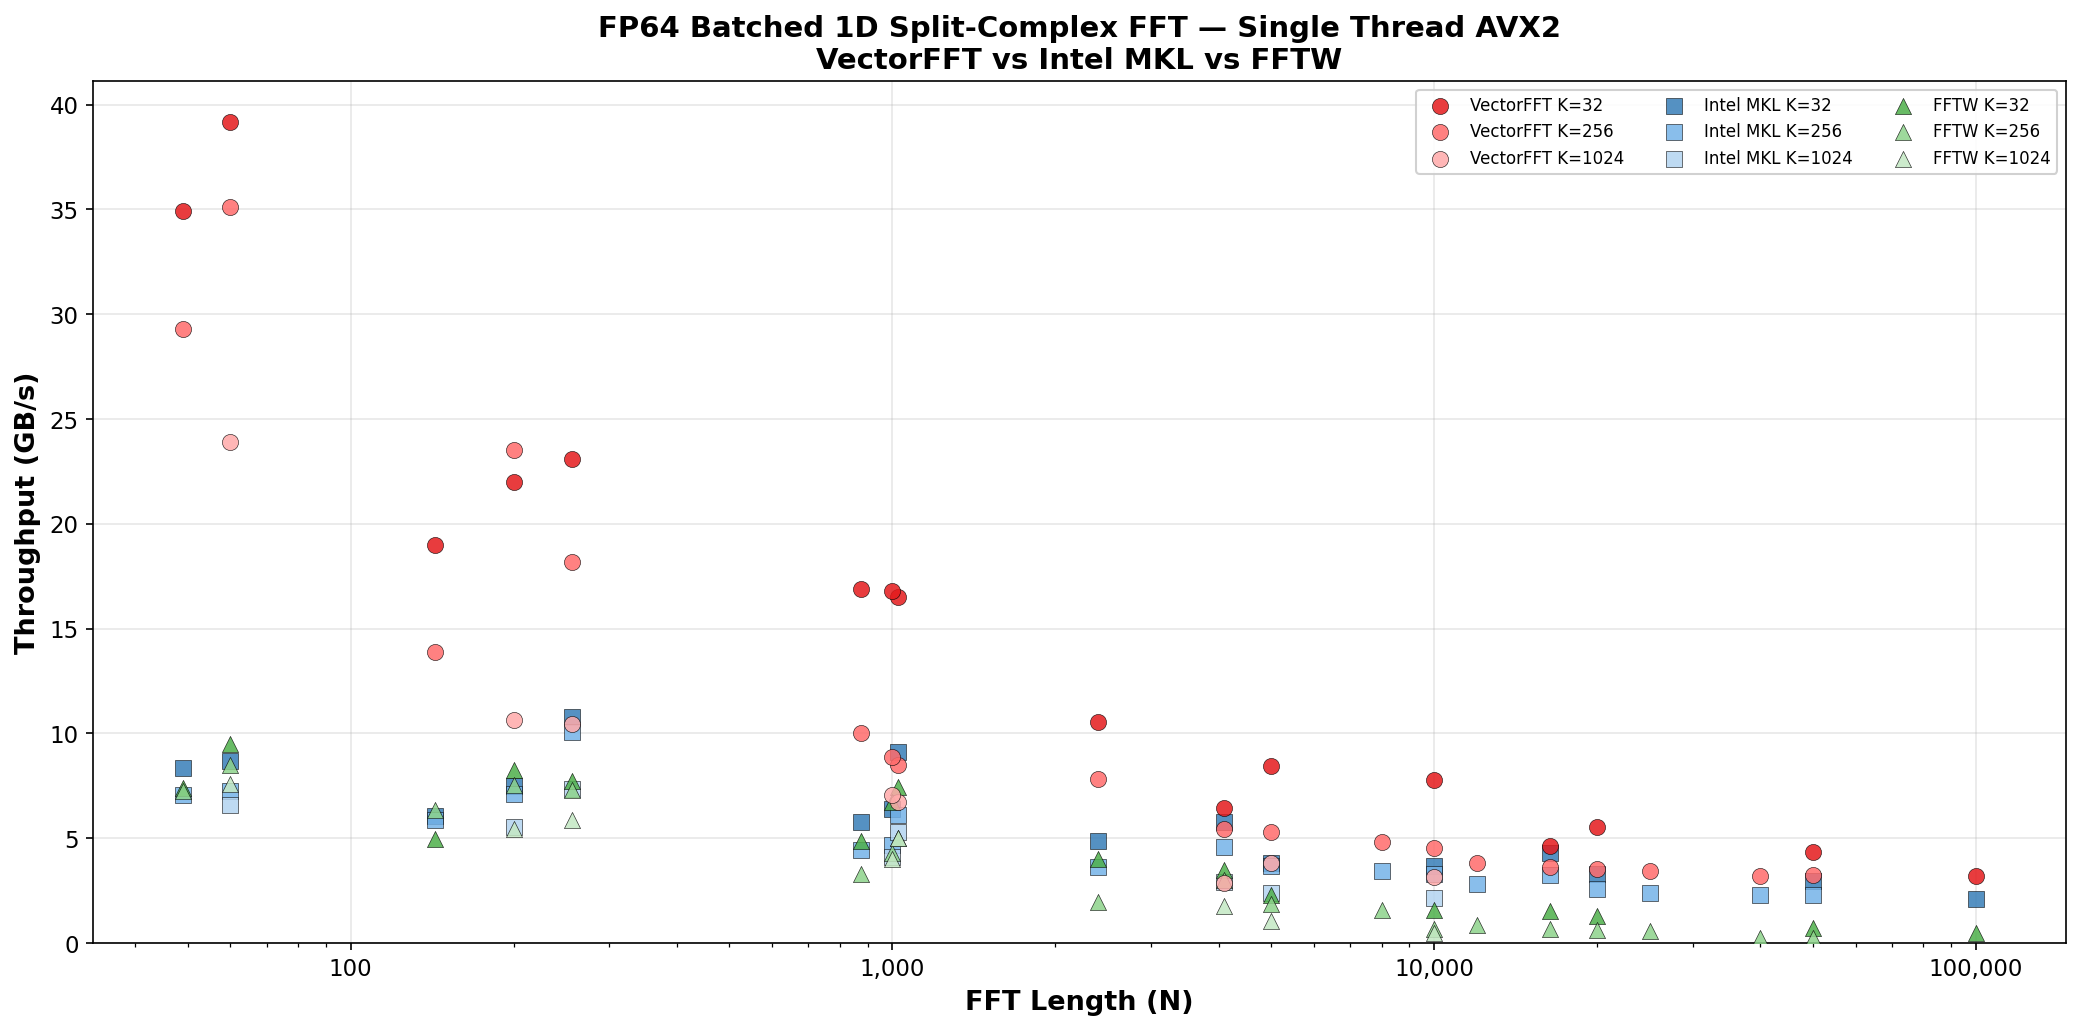

Saved: vfft_throughput.png


In [18]:
# ═══════════════════════════════════════════════════════════════
# Plot 1: Throughput (GB/s) vs FFT Length — VkFFT style
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))

# Classify N values
def is_pow2(n):
    return n > 0 and (n & (n-1)) == 0

# Color by K
k_colors = {32: 0, 256: 1, 1024: 2}

for lib, gbs, marker, base_color, label_base in [
    ('ours', ours_gbs, 'o', ['#e41a1c', '#ff6b6b', '#ffaaaa'], 'VectorFFT'),
    ('mkl',  mkl_gbs,  's', ['#377eb8', '#74b3e8', '#b3d4f0'], 'Intel MKL'),
    ('fftw', fftw_gbs, '^', ['#4daf4a', '#8dd38b', '#c4e8c3'], 'FFTW'),
]:
    for ki, K_val in enumerate([32, 256, 1024]):
        mask = K_arr == K_val
        if not np.any(mask):
            continue
        ax.scatter(N_arr[mask], gbs[mask],
                   marker=marker, s=60, alpha=0.85,
                   color=base_color[ki], edgecolors='black', linewidth=0.3,
                   label=f'{label_base} K={K_val}' if ki == 0 or True else None,
                   zorder=5 if lib == 'ours' else 3)

ax.set_xlabel('FFT Length (N)', fontsize=13, fontweight='bold')
ax.set_ylabel('Throughput (GB/s)', fontsize=13, fontweight='bold')
ax.set_title('FP64 Batched 1D Split-Complex FFT — Single Thread AVX2\n'
             'VectorFFT vs Intel MKL vs FFTW', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8, ncol=3, framealpha=0.9)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('vfft_throughput.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_throughput.png')

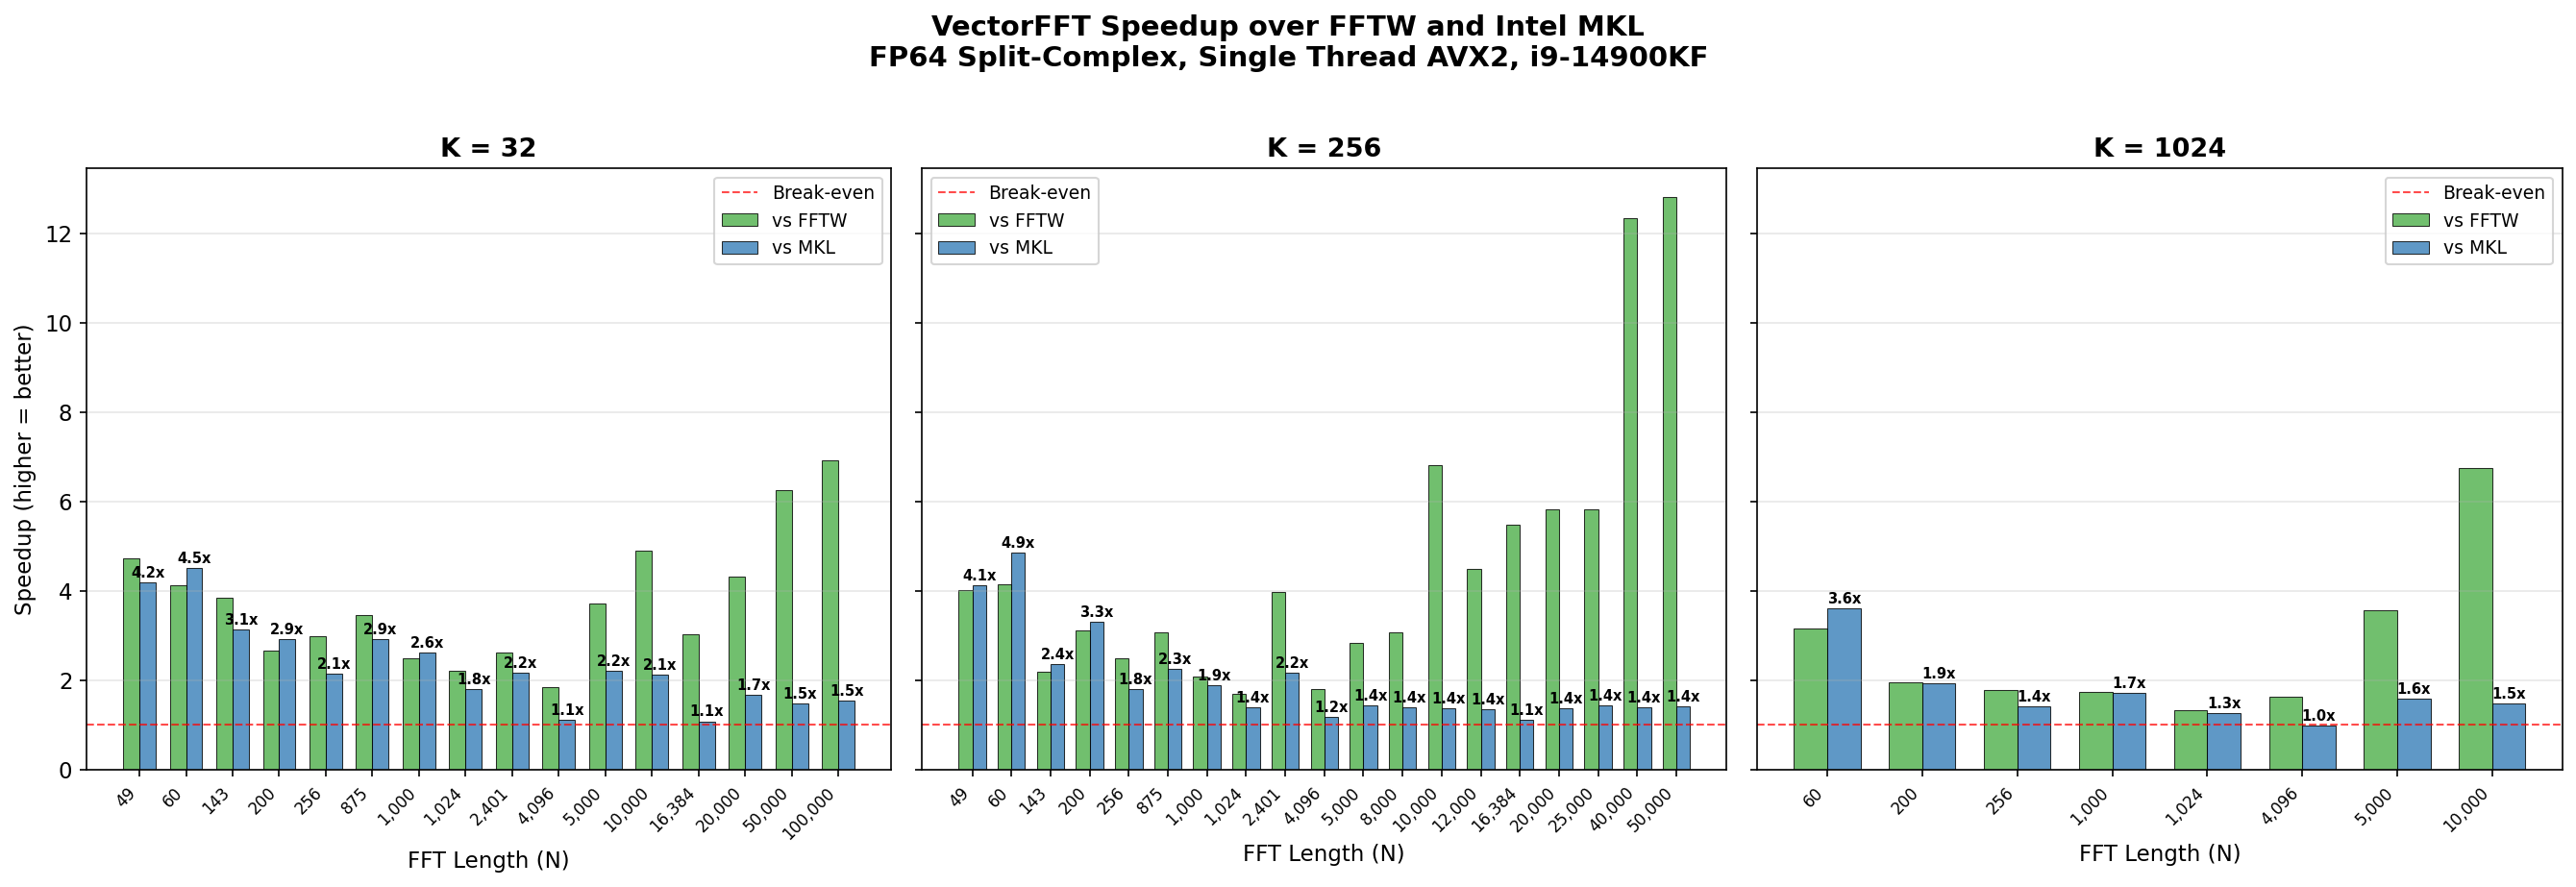

Saved: vfft_speedup_bars.png


In [19]:
# ═══════════════════════════════════════════════════════════════
# Plot 2: Speedup ratios vs N — grouped bar chart
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ki, K_val in enumerate([32, 256, 1024]):
    ax = axes[ki]
    mask = K_arr == K_val
    Ns = N_arr[mask]
    vs_fftw = fftw_ns[mask] / ours_ns[mask]
    vs_mkl  = mkl_ns[mask] / ours_ns[mask]

    # Sort by N
    order = np.argsort(Ns)
    Ns = Ns[order]
    vs_fftw = vs_fftw[order]
    vs_mkl = vs_mkl[order]

    x = np.arange(len(Ns))
    w = 0.35

    bars1 = ax.bar(x - w/2, vs_fftw, w, label='vs FFTW', color='#4daf4a', alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + w/2, vs_mkl,  w, label='vs MKL',  color='#377eb8', alpha=0.8, edgecolor='black', linewidth=0.5)

    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Break-even')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(n):,}' for n in Ns], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'K = {K_val}', fontsize=13, fontweight='bold')
    ax.set_xlabel('FFT Length (N)', fontsize=11)
    if ki == 0:
        ax.set_ylabel('Speedup (higher = better)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars2, vs_mkl):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}x', ha='center', va='bottom', fontsize=7, fontweight='bold')

fig.suptitle('VectorFFT Speedup over FFTW and Intel MKL\n'
             'FP64 Split-Complex, Single Thread AVX2, i9-14900KF',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vfft_speedup_bars.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_speedup_bars.png')

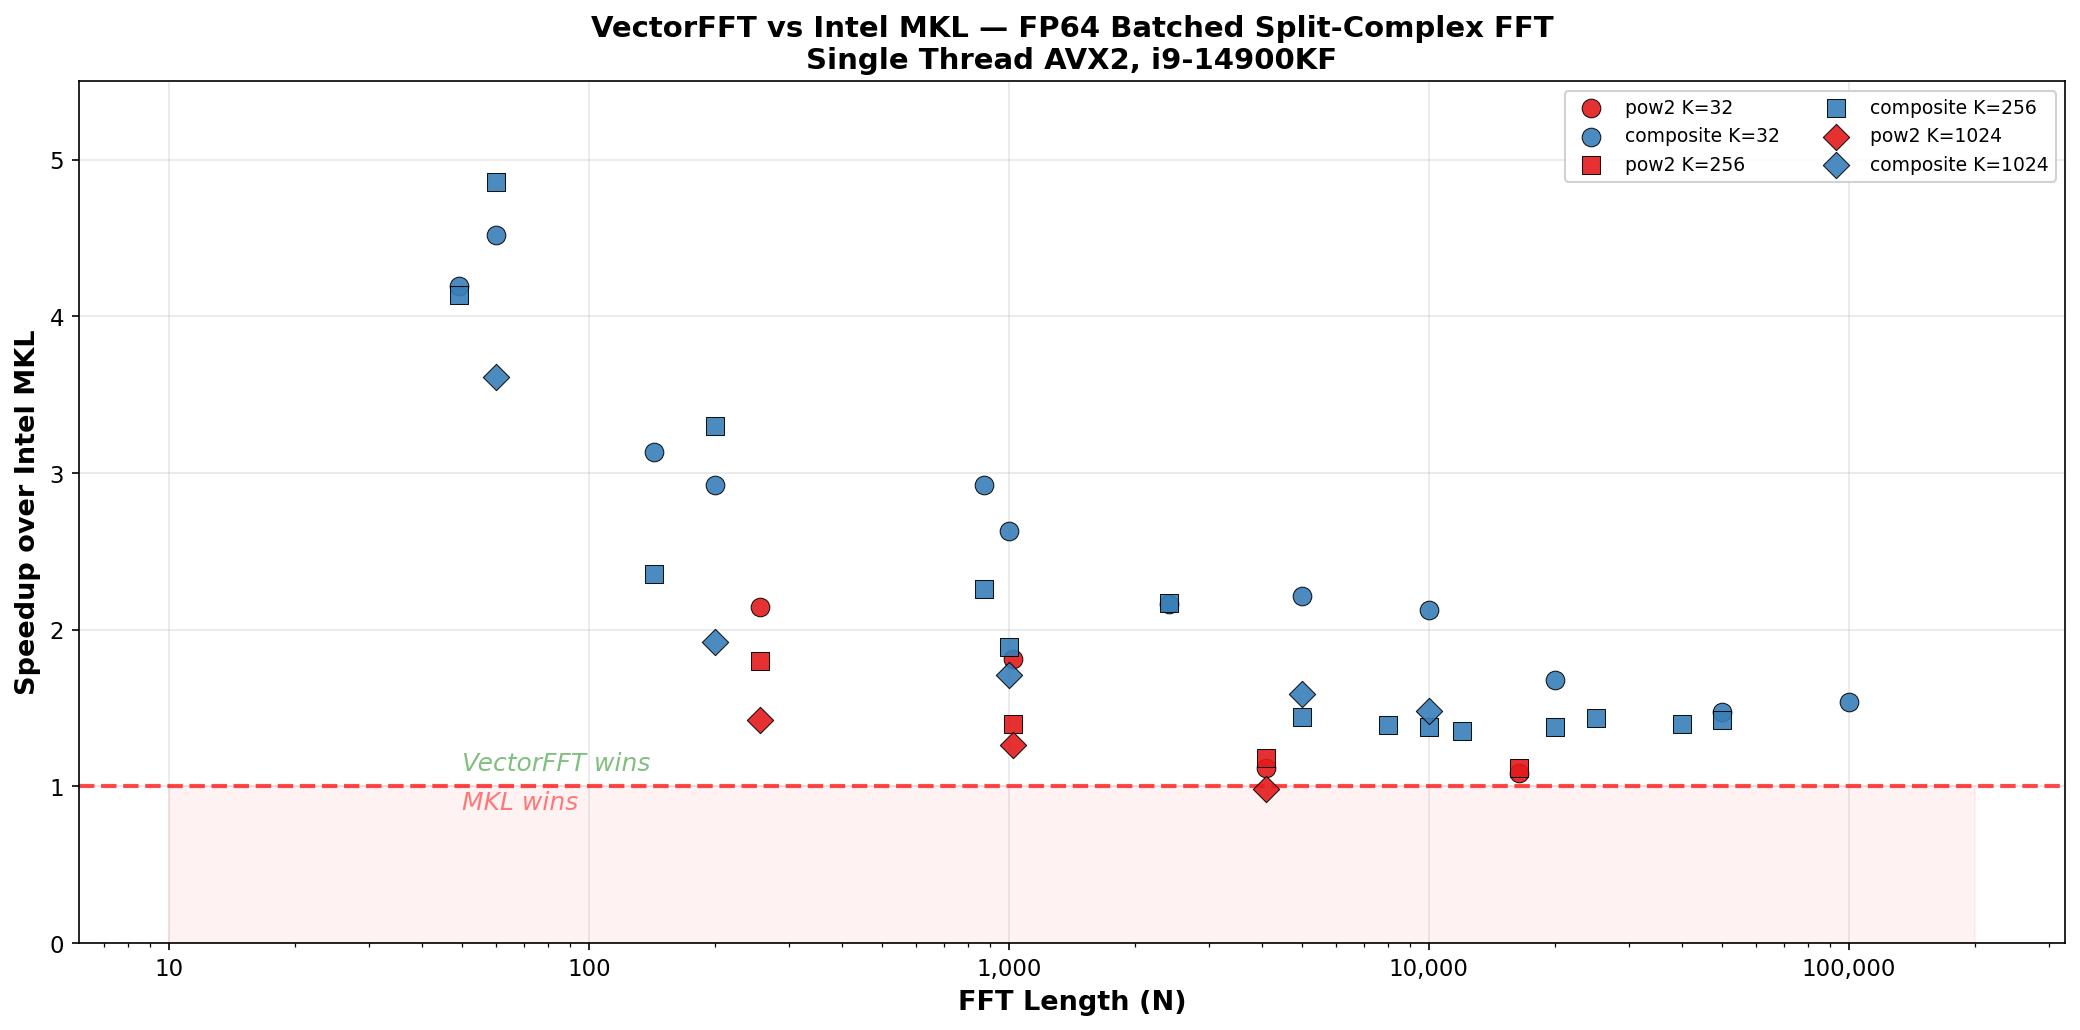

Saved: vfft_vs_mkl.png


In [20]:
# ═══════════════════════════════════════════════════════════════
# Plot 3: Speedup vs MKL as scatter — VkFFT style
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))

vs_mkl_all = mkl_ns / ours_ns
vs_fftw_all = fftw_ns / ours_ns

# Classify points
pow2_mask = np.array([is_pow2(n) for n in N_arr])
composite_mask = ~pow2_mask

for K_val, marker, size in [(32, 'o', 80), (256, 's', 80), (1024, 'D', 80)]:
    mask = K_arr == K_val

    # Pow2
    m = mask & pow2_mask
    if np.any(m):
        ax.scatter(N_arr[m], vs_mkl_all[m], marker=marker, s=size,
                   color='#e41a1c', edgecolors='black', linewidth=0.5,
                   alpha=0.9, label=f'pow2 K={K_val}', zorder=5)

    # Composite
    m = mask & composite_mask
    if np.any(m):
        ax.scatter(N_arr[m], vs_mkl_all[m], marker=marker, s=size,
                   color='#377eb8', edgecolors='black', linewidth=0.5,
                   alpha=0.9, label=f'composite K={K_val}', zorder=5)

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.fill_between([10, 200000], 0, 1, color='red', alpha=0.05)
ax.text(50, 0.85, 'MKL wins', fontsize=12, color='red', alpha=0.5, fontstyle='italic')
ax.text(50, 1.1, 'VectorFFT wins', fontsize=12, color='green', alpha=0.5, fontstyle='italic')

ax.set_xlabel('FFT Length (N)', fontsize=13, fontweight='bold')
ax.set_ylabel('Speedup over Intel MKL', fontsize=13, fontweight='bold')
ax.set_title('VectorFFT vs Intel MKL — FP64 Batched Split-Complex FFT\n'
             'Single Thread AVX2, i9-14900KF', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(0, 5.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.9)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('vfft_vs_mkl.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_vs_mkl.png')

In [21]:
# ═══════════════════════════════════════════════════════════════
# Summary statistics
# ═══════════════════════════════════════════════════════════════

vs_mkl_all = mkl_ns / ours_ns
vs_fftw_all = fftw_ns / ours_ns

print('VectorFFT vs Intel MKL:')
print(f'  Min:    {vs_mkl_all.min():.2f}x')
print(f'  Max:    {vs_mkl_all.max():.2f}x')
print(f'  Mean:   {vs_mkl_all.mean():.2f}x')
print(f'  Median: {np.median(vs_mkl_all):.2f}x')
print(f'  Wins:   {np.sum(vs_mkl_all > 1.0)}/{len(vs_mkl_all)}')
print()
print('VectorFFT vs FFTW:')
print(f'  Min:    {vs_fftw_all.min():.2f}x')
print(f'  Max:    {vs_fftw_all.max():.2f}x')
print(f'  Mean:   {vs_fftw_all.mean():.2f}x')
print(f'  Median: {np.median(vs_fftw_all):.2f}x')
print()
print('Composite N (not pow2) vs MKL:')
comp = np.array([not is_pow2(n) for n in N_arr])
print(f'  Mean:   {vs_mkl_all[comp].mean():.2f}x')
print(f'  Median: {np.median(vs_mkl_all[comp]):.2f}x')
print()
print('Pow2 N vs MKL:')
p2 = np.array([is_pow2(n) for n in N_arr])
print(f'  Mean:   {vs_mkl_all[p2].mean():.2f}x')
print(f'  Median: {np.median(vs_mkl_all[p2]):.2f}x')

VectorFFT vs Intel MKL:
  Min:    0.99x
  Max:    4.86x
  Mean:   2.08x
  Median: 1.71x
  Wins:   42/43

VectorFFT vs FFTW:
  Min:    1.34x
  Max:    12.82x
  Mean:   3.96x
  Median: 3.15x

Composite N (not pow2) vs MKL:
  Mean:   2.31x
  Median: 2.03x

Pow2 N vs MKL:
  Mean:   1.39x
  Median: 1.27x


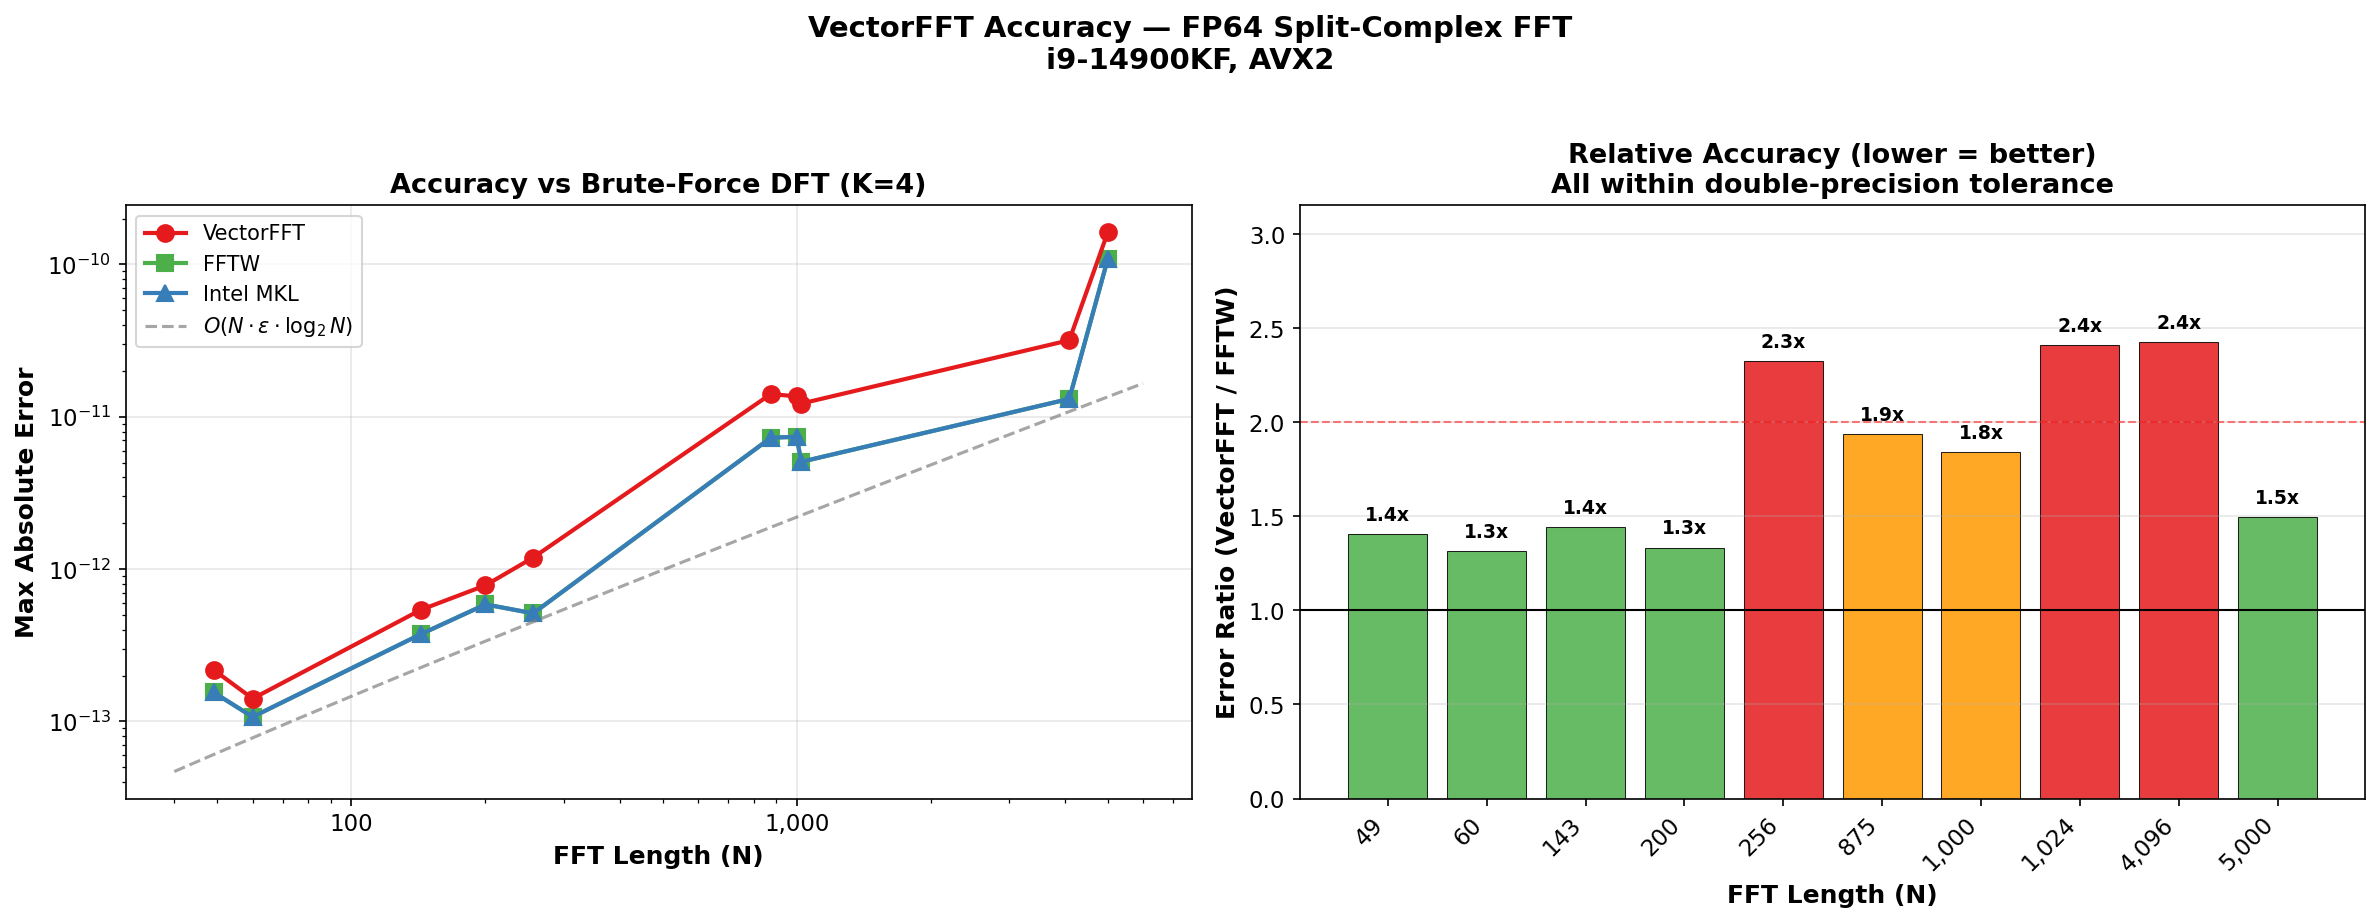

Saved: vfft_accuracy.png


In [22]:
# ═══════════════════════════════════════════════════════════════
# Plot 4: Accuracy — max absolute error vs brute-force DFT
# ═══════════════════════════════════════════════════════════════

# Accuracy data: (N, err_ours, err_fftw, err_mkl)
# Max absolute errors vs O(N^2) brute-force reference, K=4
# UPDATE these with actual values from vfft_bench output
acc_data = [
    (49,    2.18e-13, 1.55e-13, 1.55e-13),
    (60,    1.41e-13, 1.07e-13, 1.07e-13),
    (143,   5.39e-13, 3.73e-13, 3.73e-13),
    (200,   7.82e-13, 5.86e-13, 5.86e-13),
    (256,   1.19e-12, 5.12e-13, 5.12e-13),
    (875,   1.41e-11, 7.28e-12, 7.28e-12),
    (1000,  1.36e-11, 7.39e-12, 7.39e-12),
    (1024,  1.22e-11, 5.06e-12, 5.06e-12),
    (4096,  3.18e-11, 1.31e-11, 1.31e-11),
    (5000,  1.63e-10, 1.09e-10, 1.09e-10),
]

acc_N    = np.array([d[0] for d in acc_data])
acc_ours = np.array([d[1] for d in acc_data])
acc_fftw = np.array([d[2] for d in acc_data])
acc_mkl  = np.array([d[3] for d in acc_data])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: absolute error vs N
ax1.plot(acc_N, acc_ours, 'o-', color='#e41a1c', markersize=8, linewidth=2,
         label='VectorFFT', zorder=5)
ax1.plot(acc_N, acc_fftw, 's-', color='#4daf4a', markersize=8, linewidth=2,
         label='FFTW')
ax1.plot(acc_N, acc_mkl,  '^-', color='#377eb8', markersize=8, linewidth=2,
         label='Intel MKL')

# Theoretical bound: N * eps * log2(N)
eps = 2.2e-16
Ns_theory = np.logspace(np.log10(40), np.log10(6000), 100)
theory = Ns_theory * eps * np.log2(Ns_theory)
ax1.plot(Ns_theory, theory, '--', color='gray', linewidth=1.5, alpha=0.7,
         label=r'$O(N \cdot \epsilon \cdot \log_2 N)$')

ax1.set_xlabel('FFT Length (N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Max Absolute Error', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy vs Brute-Force DFT (K=4)', fontsize=13, fontweight='bold')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: error ratio (ours / fftw)
ratio = acc_ours / acc_fftw
x = np.arange(len(acc_N))
colors = ['#e41a1c' if r > 2.0 else '#ff9900' if r > 1.5 else '#4daf4a' for r in ratio]

bars = ax2.bar(x, ratio, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax2.axhline(y=1.0, color='black', linestyle='-', linewidth=1)
ax2.axhline(y=2.0, color='red', linestyle='--', linewidth=1, alpha=0.5)

for bar, val in zip(bars, ratio):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels([f'{int(n):,}' for n in acc_N], rotation=45, ha='right')
ax2.set_xlabel('FFT Length (N)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Error Ratio (VectorFFT / FFTW)', fontsize=12, fontweight='bold')
ax2.set_title('Relative Accuracy (lower = better)\nAll within double-precision tolerance', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(ratio) * 1.3)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('VectorFFT Accuracy — FP64 Split-Complex FFT\ni9-14900KF, AVX2', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vfft_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_accuracy.png')
